In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import warnings
warnings.simplefilter(action='ignore', category=ConvergenceWarning)
import json
from scipy.stats import chi2
from scipy.linalg import sqrtm
with open('config.json', 'r') as f:
    config = json.load(f)

Analyzing denoising strategy: acompcor


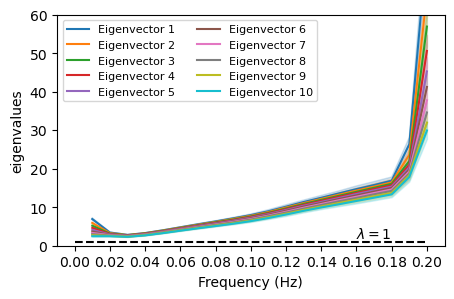

In [20]:
denoising_strategies = config['strategies']
for strategy in denoising_strategies:
    if strategy != 'acompcor':
        continue
    plt.figure(figsize=(5,3))
    print(f'Analyzing denoising strategy: {strategy}')
    df_ged = pd.read_csv('data/ged_results/ged_eigenvalues_'+strategy+'.csv')
    for i in range(10):
        sns.lineplot(data=df_ged[df_ged['eigenvector_index'] == i+1], x='frequency', y='eigenvalues', label=f'Eigenvector {i+1}')
    plt.ylim(0,60)
    plt.legend(ncol=2, fontsize=8)
    # plt.yscale('log')
    plt.xticks(np.arange(0,0.21,0.02))
    plt.xlabel('Frequency (Hz)')
    plt.hlines(y=1, xmin=0, xmax=0.2, color='black', linestyle='--')
    plt.text(0.16, 2, r'$\lambda=1$', color='black')
    # plt.text(0.15, 2, 'Null value', fontsize=8)
    plt.show()

Analyzing denoising strategy: acompcor


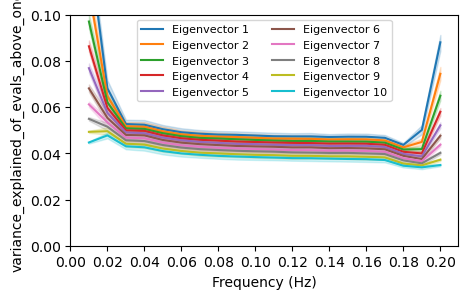

In [35]:
denoising_strategies = config['strategies']
for strategy in denoising_strategies:
    if strategy != 'acompcor':
        continue
    plt.figure(figsize=(5,3))
    print(f'Analyzing denoising strategy: {strategy}')
    df_ged = pd.read_csv('data/ged_results/ged_eigenvalues_'+strategy+'.csv')
    for i in range(10):
        sns.lineplot(data=df_ged[df_ged['eigenvector_index'] == i+1], x='frequency', y='variance_explained_of_evals_above_one', label=f'Eigenvector {i+1}')
    plt.ylim(0,0.1)
    plt.legend(ncol=2, fontsize=8)
    # plt.yscale('log')
    plt.xticks(np.arange(0,0.21,0.02))
    plt.xlabel('Frequency (Hz)')
    # plt.hlines(y=1, xmin=0, xmax=0.2, color='black', linestyle='--')
    # plt.text(0.16, 2, r'$\lambda=1$', color='black')
    # plt.text(0.15, 2, 'Null value', fontsize=8)
    plt.show()

In [22]:
def plot_ged_frequencies(df_ged):
    frequencies = df_ged['frequency'].unique()
    
    plt.subplots(5,4, figsize=(10,10), tight_layout=True)
    for freq in frequencies:
        ax = plt.subplot(5,4,np.where(frequencies==freq)[0][0]+1)
        subset = df_ged[(df_ged['frequency'] == freq) & (df_ged['eigenvector_index'] == 1)]
        # if any inf in eigenvalues, remove those rows
        subset = subset.replace([np.inf, -np.inf], np.nan)
        # remove missing values in the PPL_mcg/L column
        subset = subset.dropna(subset=['PPL_mcg/L', 'eigenvalues'])
        ax.plot(subset['PPL_mcg/L'], subset['eigenvalues'], 'o')
        # add line of best fit
        m, b = np.polyfit(subset['PPL_mcg/L'], subset['eigenvalues'], 1)
        ax.plot(subset['PPL_mcg/L'], m*subset['PPL_mcg/L'] + b, color='red')

        # find the p-value of the correlation
        m0 = MixedLM.from_formula("eigenvalues ~ 1 + age+sex+scanner", groups="subject", data=subset).fit(reml=False)

        # Fit full model to get coefficient for covariate
        formula_full = "eigenvalues ~ 1 + age+sex+scanner + PPL_mcg_L"
        m1 = MixedLM.from_formula(formula_full, groups="subject", data=subset).fit(reml=False)
        LRT_val = 2 * (m1.llf - m0.llf)
        pval = chi2.sf(LRT_val, 1)

        ax.set_title(f'{freq:.3f} Hz, p={pval:.3f}')
        if np.where(frequencies==freq)[0][0]//4 == 4:
            ax.set_xlabel('PPL (mcg/L)')
        if np.where(frequencies==freq)[0][0]%4 == 0:
            ax.set_ylabel('Leading GED Eigenvalue')

Analyzing denoising strategy: acompcor


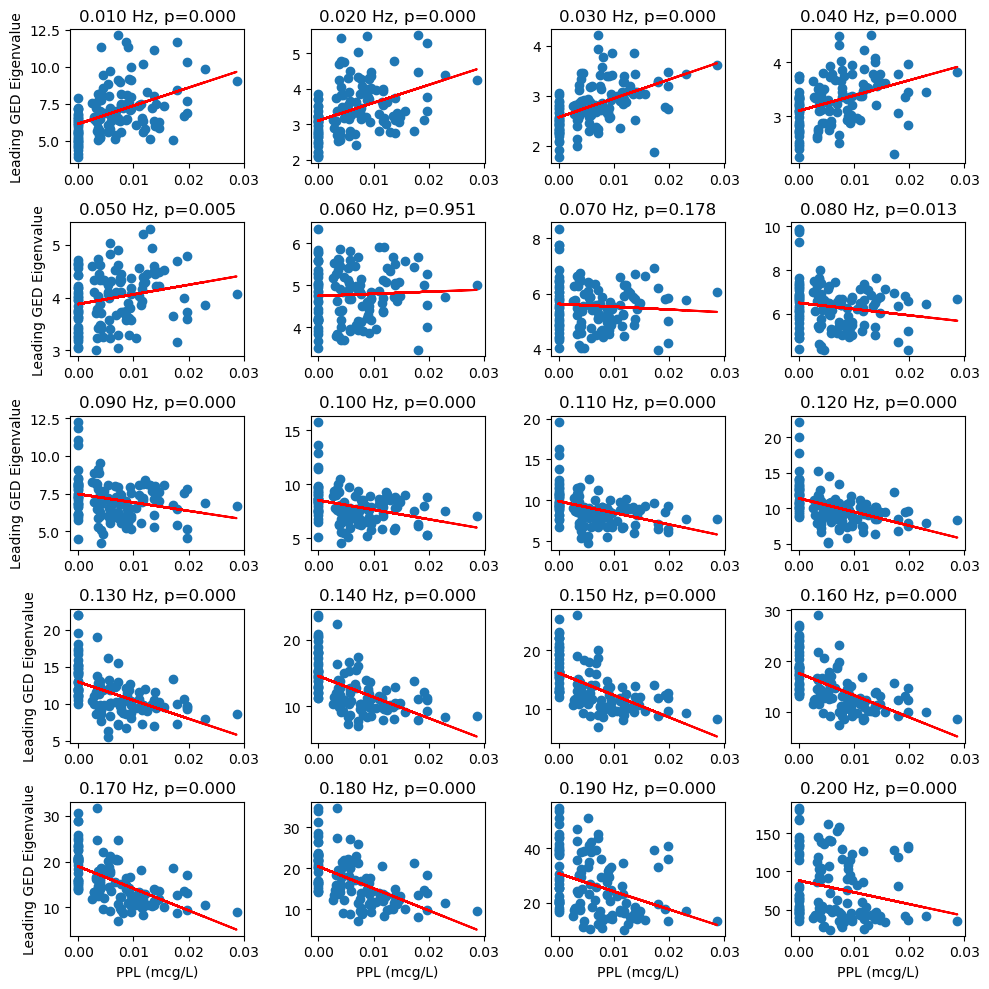

In [23]:
denoising_strategies = config['strategies']
for strategy in denoising_strategies:
    if strategy != 'acompcor':
        continue
    print(f'Analyzing denoising strategy: {strategy}')
    df_ged = pd.read_csv('data/ged_results/ged_eigenvalues_'+strategy+'.csv')
    df_ged['PPL_mcg_L'] = df_ged['PPL_mcg/L']
    plot_ged_frequencies(df_ged)
    plt.show()

In [24]:
def plot_partial_residuals(df_ged, config):
    frequencies = df_ged['frequency'].unique()
    
    plt.subplots(1,5, figsize=(15,3), tight_layout=True)
    for eigenvector_index in range(1,6):
        ax = plt.subplot(1,5,eigenvector_index)
        for freq in frequencies:
            subset = df_ged[(df_ged['frequency'] == freq) & (df_ged['eigenvector_index'] == eigenvector_index)]
            # if any inf in eigenvalues, remove those rows
            subset = subset.replace([np.inf, -np.inf], np.nan)
            # remove missing values in the PPL_mcg/L column
            subset = subset.dropna(subset=['PPL_mcg/L', 'eigenvalues'])

            # find the p-value of the correlation
            m0 = MixedLM.from_formula("eigenvalues ~ 1 + age+sex+scanner", groups="subject", data=subset).fit(reml=False)
            # get partial residuals for PPL_mcg_L
            # subset['partial_residuals'] = subset['eigenvalues'] - m0.fittedvalues
            X0 = m0.model.exog[:,1:] # exclude intercept
            beta0 = m0.fe_params.values[1:] 
            partial_residuals = subset['eigenvalues'] - X0 @ np.atleast_1d(beta0)
            df_ged.loc[subset.index, 'partial_residuals'] = partial_residuals

        category_cols = ['subject', 'time_interval', 'frequency']
        numeric_cols = ['partial_residuals']
        spectrum_df_avg_within_subject = df_ged.groupby(category_cols, as_index=False)[numeric_cols].mean()
        spectrum_df_avg = spectrum_df_avg_within_subject.groupby(['time_interval', 'frequency'], as_index=False)[numeric_cols].mean()

        sns.lineplot(data=spectrum_df_avg_within_subject, x='frequency', y='partial_residuals',hue='time_interval', ax=ax, hue_order=config['time_intervals'].keys())
        ax.set_title(f'Eigenvector {eigenvector_index}')
        if eigenvector_index == 1:
            ax.set_ylabel('Partial Residuals of Eigenvalues')
        else:
            ax.set_ylabel('')
        if eigenvector_index == 5:
            ax.legend(title='Time Interval', bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            ax.get_legend().remove()
        ax.set_xlabel('frequency [Hz]')
        ax.set_ylim(0,40)
        # horizontal line at y=1
        ax.axhline(y=1, color='black', linestyle='--')
        ax.text(0.16, 2, r'$\lambda=1$', color='black')

Analyzing denoising strategy: acompcor


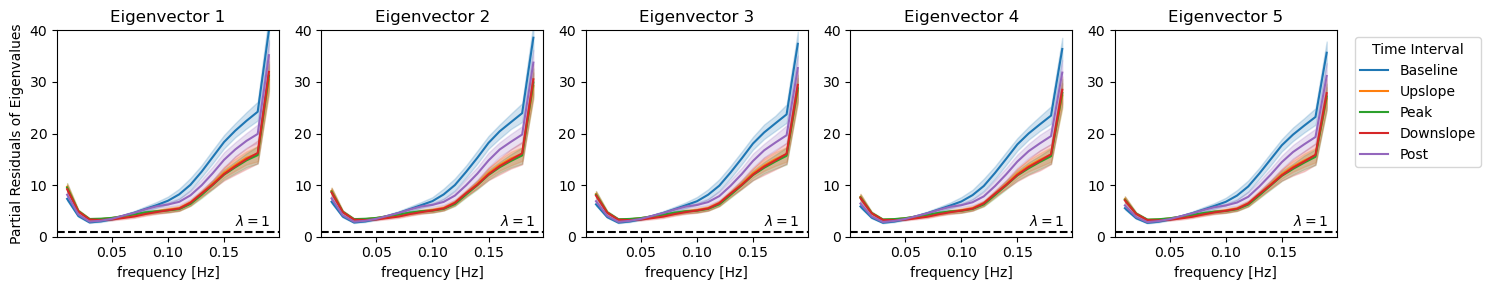

In [25]:
denoising_strategies = config['strategies']
for strategy in denoising_strategies:
    if strategy != 'acompcor':
        continue
    print(f'Analyzing denoising strategy: {strategy}')
    df_ged = pd.read_csv('data/ged_results/ged_eigenvalues_'+strategy+'.csv')
    df_ged['PPL_mcg_L'] = df_ged['PPL_mcg/L']
    df_ged = df_ged[df_ged['frequency']<0.2] 
    plot_partial_residuals(df_ged, config)
    plt.show()

In [26]:
frequencies = np.round(np.sort(df_ged['frequency'].unique()),decimals=3)

In [38]:
# for only acompcor, load the eigenvectors and display the average correlation structure over frequencies (average over subejcts)
import os
strategy = 'acompcor'
print(f'Analyzing denoising strategy: {strategy}')
df = pd.read_csv('data/func_scans_table_outliers_ses-PSI_task-rest_PPLSDI.csv')
df = df[df['task']==config["task"]]
df = df[df['include_scan_coil_numvols']]
df = df[df['include_manual_qc']]
df = df[df['ratio_outliers_fd0.5_std_dvars1000'] < config["max_ratio_outliers_fd0.5_std_dvars1000"]]
df = df[df['max_fd'] < config["scan_max_fd_threshold"]]

#### Load covariance matrices #####
ppl_list = {}
cov_broadband_list = {}
cov_broadband_sqrtm_list = {}
cov_narrowband_list = {}
skip_idx = []
for index, scan in df.iterrows():
    output_dir = 'data/ged_results/'+strategy+'/' + scan.subject + '/' + scan.session + '/func/'
    ppl_list[index] = scan['PPL_mcg/L']
    cov_broadband = np.load(os.path.join(output_dir, os.path.basename(scan['preproc_filename_cifti']).replace('.dtseries.nii', '_ged_broadband_covariance.npy')))
    if np.any(np.isnan(cov_broadband)):
        print(f'Skipping scan {scan.subject} {scan.session} due to NaNs in broadband covariance')
        skip_idx.append(index)
        continue
    cov_narrowband = np.load(os.path.join(output_dir, os.path.basename(scan['preproc_filename_cifti']).replace('.dtseries.nii', '_ged_narrowband_covariances.npy')))
    cov_broadband_list[index] = cov_broadband.real
    cov_broadband_sqrtm_list[index] = sqrtm(cov_broadband).real
    cov_narrowband_list[index] = cov_narrowband.real

##### Load eigenvectors #####
all_eigenvectors_list = []
all_weighted_eigenvectors_list = []
all_orthonormal_eigenvectors_list = []
all_orthonormal_weighted_eigenvectors_list = []
for freq in frequencies:
    freq_eigenvectors_list = []
    freq_weighted_eigenvectors_list = []
    freq_orthonormal_eigenvectors_list = []
    freq_orthonormal_weighted_eigenvectors_list = []
    for index, scan in df.iterrows():
        output_dir = 'data/ged_results/'+strategy+'/' + scan.subject + '/' + scan.session + '/func/'
        eigenvectors = np.load(os.path.join(output_dir, os.path.basename(scan['preproc_filename_cifti']).replace('.dtseries.nii', '_freq_'+str(freq)+'_ged_leading_eigenvectors.npy')))
        eigenvectors = eigenvectors.real
        if np.any(np.isnan(eigenvectors)):
            # print(f'Skipping scan {scan.subject} {scan.session} due to NaNs in eigenvectors')
            continue
        for ev in range(eigenvectors.shape[-1]):
            if np.sum(eigenvectors[:,ev]>0)> np.sum(eigenvectors[:,ev]<0):
                eigenvectors[:,ev] *= -1  # flip sign for consistency
        # eigenvalues = df_ged[(df_ged['subject'] == scan.subject) & (df_ged['scan_min_since_admin'] == scan.scan_min_since_admin) & (np.round(df_ged['frequency'],decimals=3) == freq )]['eigenvalues'].values
        # eigenvectors_weighted[f,:,:] = eigenvectors[f,:,:] * np.sqrt(eigenvalues)[None,:]
        varexpl = df_ged[(df_ged['subject'] == scan.subject) & (df_ged['scan_min_since_admin'] == scan.scan_min_since_admin) & (np.round(df_ged['frequency'],decimals=3) == freq )]
        # sort varexpl by eigenvector_index and provide values
        varexpl = varexpl.sort_values(by='eigenvector_index')['variance_explained_of_evals_above_one'].values
        eigenvectors_weighted = eigenvectors * varexpl[None,:]
        freq_eigenvectors_list.append(eigenvectors)
        freq_weighted_eigenvectors_list.append(eigenvectors_weighted)
        freq_orthonormal_eigenvectors_list.append(cov_broadband_sqrtm_list[index] @ eigenvectors)
        freq_orthonormal_weighted_eigenvectors_list.append(cov_broadband_sqrtm_list[index] @ eigenvectors_weighted)

    all_eigenvectors_list.append(freq_eigenvectors_list)
    all_weighted_eigenvectors_list.append(freq_weighted_eigenvectors_list)
    all_orthonormal_eigenvectors_list.append(freq_orthonormal_eigenvectors_list)
    all_orthonormal_weighted_eigenvectors_list.append(freq_orthonormal_weighted_eigenvectors_list)

Analyzing denoising strategy: acompcor
Skipping scan sub-56726 ses-PSI due to NaNs in broadband covariance
Skipping scan sub-57132 ses-PSI due to NaNs in broadband covariance


In [28]:
# from spectral_analysis.helper_functions import import_mask_and_parcellation
# import nilearn.surface as surface
# import nilearn.plotting as plotting
# from time import time
# os.makedirs('figures/ged_subject_specific_maps/', exist_ok=True)
# parcel_labels, parcellation, masks, parcellation_extended = import_mask_and_parcellation()
# unique_parcels = np.unique(parcellation)
# unique_parcels = unique_parcels[unique_parcels != 0]  # remove background parcel
# fsLR_surface_L = surface.load_surf_mesh('data/external/fs_LR.32k.L.midthickness.surf.gii')
# fsLR_surface_R = surface.load_surf_mesh('data/external/fs_LR.32k.R.midthickness.surf.gii')
# fsLR_surface = {'lh': fsLR_surface_L, 'rh': fsLR_surface_R}
# for scan in range(eigenvectors_array.shape[0]):
#     for freq in range(eigenvectors_array.shape[1]):
#         for eigenvector in range(eigenvectors_array.shape[-1]): 
#             # spatial_map = spatial_maps_array[scan,freq,:,eigenvector]
#             spatial_map = orthonormal_eigenvectors_array[scan,freq,:,eigenvector]
#             # spatial_map = eigenvectors_array[scan,freq,:,eigenvector]
#             if np.sum(spatial_map>0)> np.sum(spatial_map<0):
#                 spatial_map = -spatial_map  # flip sign for visualization consistency
#             for hemi in ['lh', 'rh']:
#                 t1 = time()
#                 if hemi=='lh':
#                     h2 = 'left'
#                 elif hemi=='rh':
#                     h2 = 'right'
#                 cortex_map = np.empty(masks['mask_'+hemi].shape)
#                 cortex_map.fill(np.nan)
#                 for roi_label, roi_number in zip(parcel_labels,unique_parcels):
#                     if hemi.upper() in roi_label:
#                         cortex_map[parcellation_extended['parcellation_'+hemi+'_expanded']==roi_number] = spatial_map[roi_number-1]

#                 t2 = time()
#                 print(f'Plotting scan {scan+1}/{spatial_maps_array.shape[0]}, freq {frequencies[freq]:.3f} Hz, eigenvector {eigenvector+1}, hemi {hemi}, time taken: {t2-t1:.2f} seconds')
#                 for view in ['lateral']:# medial
#                     plotting.plot_surf(fsLR_surface[hemi],cortex_map,symmetric_cmap=None,bg_on_data=False,colorbar=True, 
#                                         cmap='bwr', vmin=-0.2, vmax=0.2, darkness=None, hemi=h2,view=view,
#                                         output_file='figures/ged_subject_specific_maps/'+strategy+'_'+str(scan)+'_'+str(frequencies[freq])+'_'+str(eigenvector)+'_'+hemi+'_'+view+'.png')
#                     t3 = time()
#                     print(f'  Plot generated in {t3-t2:.2f} seconds')
#                     plt.close()


In [29]:
def procrustes_distance(A, B):
    """
    Compute the Procrustes distance between two orthonormal basis matrices A and B.

    Parameters
    ----------
    A : np.ndarray
        Orthonormal basis matrix of size (P, Q)
    B : np.ndarray
        Orthonormal basis matrix of size (P, Q)

    Returns
    -------
    distance : float
        Procrustes distance between subspaces spanned by A and B.
    """
    U, _, Vt = np.linalg.svd(A.T @ B)
    R = Vt.T @ U.T
    aligned = B @ R
    distance = np.linalg.norm(A - aligned, 'fro')**2
    return aligned, distance

def procrustes_distance_unequal_frames(A, B):
    """
    Compute the Procrustes distance between two orthonormal basis matrices A and B.
    Specific for the case where A and B have different number of columns (frames).

    Parameters
    ----------
    A : np.ndarray
        Orthonormal basis matrix of size (P, Q1)
    B : np.ndarray
        Orthonormal basis matrix of size (P, Q2)

    Constrained such that P >= Q2 >= Q1

    Returns
    -------
    distance : float
        Procrustes distance between subspaces spanned by A and B.
    
    Source: 
    THE PROCRUSTES PROBLEM FOR ORTHOGONAL STIEFEL MATRICES∗
    """

    # original aim: minimize || A - B @ R ||_F^2 where R is a Stiefel matrix R^T @ R = I
    # acc to paper, we can solve || A_bar - S @ Q||_F^2
    # where A_bar = U.T @ A from SVD: B = U S Vt

    if B.shape[1] == A.shape[1]:
        return procrustes_distance(A, B)

    assert B.shape[1] > A.shape[1], "B must have equal or more columns than A"

    U,S,Vt = np.linalg.svd(B, full_matrices=False)

    # minimize || Ut @ A - S @ Vt @ R ||_F^2
    A_tilde = U.T @ A
    P,_,Rt = np.linalg.svd(np.diag(S) @ A_tilde, full_matrices=False)
    Q_tilde = P @ Rt

    # get original rotation
    Q = Vt.T @ Q_tilde
    B_aligned = B @ Q
    distance = np.linalg.norm(A - B_aligned, 'fro')**2

    return B_aligned, distance

def procrustes_distance_to_mean(mean_basis, bases):
    """
    Procrustes distance of multiple bases to a mean basis.
    """
    N = len(bases)

    aligned_all = []
    distance = np.zeros(N)
    # Align each subspace to current mean
    for i, B in enumerate(bases):
        aligned, distance[i] = procrustes_distance_unequal_frames(mean_basis, B)
        aligned_all.append(aligned)
    return aligned_all, distance

def generalized_procrustes_subspaces(bases, size_of_mean=10, tol=1e-9, max_iter=1000):
    """
    Generalized Procrustes Analysis (GPA) for subspaces.

    Each subspace is represented by an orthonormal basis matrix of size (P, Q).
    The algorithm aligns all subspaces by optimal orthogonal transforms
    to minimize the total Frobenius distance.

    Parameters
    ----------
    bases : np.ndarray
        Array of shape (N, P, Q)
        Each element bases[i] is an orthonormal basis of subspace i.
    tol : float
        Convergence tolerance (default 1e-9)
    max_iter : int
        Maximum number of iterations (default 1000)

    Returns
    -------
    aligned_bases : np.ndarray
        Array of shape (N, P, Q), aligned orthonormal bases.
    mean_basis : np.ndarray
        Orthonormal mean basis of size (P, Q).
    """
    P, _ = bases[0].shape

    # Ensure each basis is orthonormal
    # bases = np.array([np.linalg.qr(b)[0] for b in bases])

    # Initialize mean basis
    mean_basis = bases[0][:, :size_of_mean]
    delta_all = []

    for _ in range(max_iter):
        aligned, distance = procrustes_distance_to_mean(mean_basis, bases)

        # Compute new mean subspace
        M = np.zeros((P, P))
        for A in aligned:
            M += (A@A.T).real
        # Re-orthogonalize mean
        # new_mean, _ = np.linalg.qr(M)
        eigenvalues, eigenvectors = np.linalg.eig(M)
        # Sort eigenvectors by eigenvalues in descending order
        idx = eigenvalues.argsort()[::-1]
        eigenvalues = eigenvalues[idx].real
        eigenvectors = eigenvectors[:,idx].real
        new_mean = eigenvectors[:, :size_of_mean] * np.sqrt(eigenvalues[:size_of_mean])[None, :]

        # Check convergence (principal angle change)
        delta = np.linalg.norm(mean_basis - new_mean)
        mean_basis = new_mean
        bases = aligned
        delta_all.append(delta)
        if delta < tol:
            break

    return aligned, mean_basis, distance, eigenvalues[:size_of_mean], delta_all

In [30]:
# procrustes
aligned_all = []
mean_basis_all = []
distances_all = []
for f,freq in enumerate(frequencies):
    print(f'Procrustes alignment at frequency {freq:.3f} Hz')
    # aligned[:,freq], mean_basis[freq], distances[:,freq], _, _ = generalized_procrustes_subspaces(all_orthonormal_eigenvectors_list[f], tol=1e-9, max_iter=1000)
    aligned, mean_basis, distances, _, _ = generalized_procrustes_subspaces(all_orthonormal_weighted_eigenvectors_list[f], tol=1e-9, max_iter=1000)
    aligned_all.append(aligned)
    mean_basis_all.append(mean_basis)
    distances_all.append(distances)

Procrustes alignment at frequency 0.010 Hz
Procrustes alignment at frequency 0.020 Hz
Procrustes alignment at frequency 0.030 Hz
Procrustes alignment at frequency 0.040 Hz
Procrustes alignment at frequency 0.050 Hz
Procrustes alignment at frequency 0.060 Hz
Procrustes alignment at frequency 0.070 Hz
Procrustes alignment at frequency 0.080 Hz
Procrustes alignment at frequency 0.090 Hz
Procrustes alignment at frequency 0.100 Hz
Procrustes alignment at frequency 0.110 Hz
Procrustes alignment at frequency 0.120 Hz
Procrustes alignment at frequency 0.130 Hz
Procrustes alignment at frequency 0.140 Hz
Procrustes alignment at frequency 0.150 Hz
Procrustes alignment at frequency 0.160 Hz
Procrustes alignment at frequency 0.170 Hz
Procrustes alignment at frequency 0.180 Hz
Procrustes alignment at frequency 0.190 Hz


In [31]:
# take the mean basis over frequencies
aligned_mean_basis, grand_mean_basis, distances_mean, eigenvalues_grand, delta = generalized_procrustes_subspaces(mean_basis_all, tol=1e-9, max_iter=1000)

# now realign
aligned2_all = []
for f,freq in enumerate(frequencies):
    # aligned2[:,freq], dis = procrustes_distance_to_mean(aligned_mean_basis[f], all_orthonormal_eigenvectors_list[f])
    aligned2, dis = procrustes_distance_to_mean(aligned_mean_basis[f], all_orthonormal_weighted_eigenvectors_list[f])
    aligned2_all.append(aligned2)

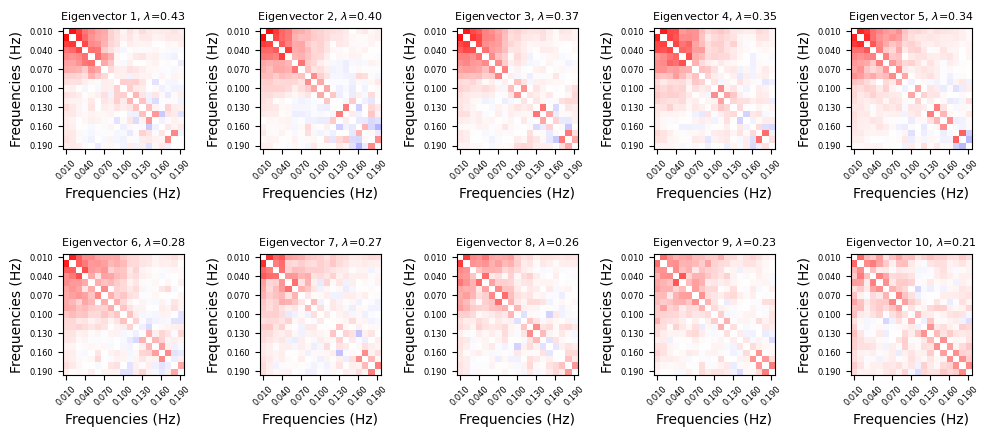

In [32]:
p=200
df_ged_reduced = df_ged[(df_ged['eigenvector_index'] == 1)&(df_ged['frequency']==0.01)]
corr_all = []
ppl_array = np.array(ppl_list)
corr_evecs  = []
fig,axs = plt.subplots(2,5, figsize=(10,5), tight_layout=True)
for j in range(10):  # iterate over eigenvectors
    ax = plt.subplot(2,5,j+1)
    # corr = (eigvecs @ eigvecs.T)**2  # shape: (num_vertices, num_vertices)
    corr = np.corrcoef(np.array(aligned_mean_basis).real[:,:,j])  # shape: (num_vertices, num_vertices)
    corr[np.diag_indices_from(corr)] = np.nan  # set diagonal to nan

    ax.imshow(corr, cmap='bwr', vmin=-1, vmax=1)
    # set frequencies as xticks and yticks
    freqs = np.arange(len(frequencies))
    # set xticks but only every 5th to avoid clutter
    ax.set_xticks(ticks=np.arange(0, len(freqs), 3), labels=[f'{frequencies[freq]:.3f}' for freq in np.arange(0, len(freqs), 3)], rotation=45, fontsize=6)
    ax.set_yticks(ticks=np.arange(0, len(freqs), 3), labels=[f'{frequencies[freq]:.3f}' for freq in np.arange(0, len(freqs), 3)], fontsize=6)
    ax.set_title(f'Eigenvector {j+1}, '+r'$\lambda$' + f'={eigenvalues_grand[j]:.2f}', fontsize=8)
    ax.set_xlabel('Frequencies (Hz)')
    ax.set_ylabel('Frequencies (Hz)')
fig.savefig('figures/ged_procrustes_correlation_matrix_'+strategy+'.png', dpi=300)

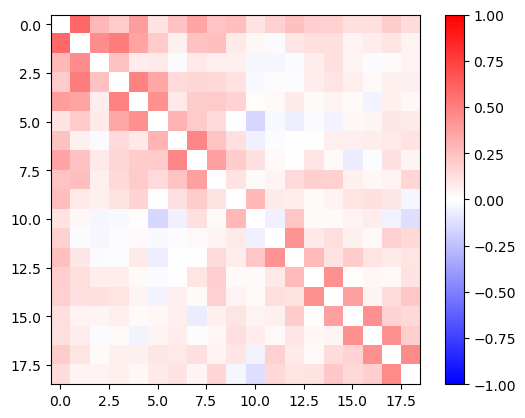

In [33]:
# make a colorbar frmo0 to 0.5 with reds
plt.imshow(corr, cmap='bwr', vmin=-1, vmax=1)
plt.colorbar()

In [34]:
from spectral_analysis.helper_functions import import_mask_and_parcellation
import nilearn.surface as surface
import nilearn.plotting as plotting
parcel_labels, parcellation, masks, parcellation_extended = import_mask_and_parcellation()
unique_parcels = np.unique(parcellation)
unique_parcels = unique_parcels[unique_parcels != 0]  # remove background parcel
fsLR_surface_L = surface.load_surf_mesh('data/external/fs_LR.32k.L.midthickness.surf.gii')
fsLR_surface_R = surface.load_surf_mesh('data/external/fs_LR.32k.R.midthickness.surf.gii')
fsLR_surface = {'lh': fsLR_surface_L, 'rh': fsLR_surface_R}

def plot_surf(spatial_map, output_file, vmin, vmax):
    if np.sum(spatial_map>0)> np.sum(spatial_map<0):
        spatial_map = -spatial_map  # flip sign for visualization consistency
    for hemi in ['lh', 'rh']:
        if hemi=='lh':
            h2 = 'left'
        elif hemi=='rh':
            h2 = 'right'
        cortex_map = np.empty(masks['mask_'+hemi].shape)
        cortex_map.fill(np.nan)
        for roi_label, roi_number in zip(parcel_labels,unique_parcels):
            if hemi.upper() in roi_label:
                cortex_map[parcellation_extended['parcellation_'+hemi+'_expanded']==roi_number] = spatial_map[roi_number-1]
        
        for view in ['lateral']:# medial
            plotting.plot_surf(fsLR_surface[hemi],cortex_map,symmetric_cmap=None,bg_on_data=False,colorbar=True, 
                                cmap='bwr', vmin=vmin, vmax=vmax, darkness=None, hemi=h2,view=view,
                                output_file=output_file+'_'+hemi+'_'+view+'.png')

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


In [36]:
os.makedirs('figures/ged_mean_basis_maps/', exist_ok=True)
strategy = 'acompcor'

# plot grand mean
for eigenvector in [0]: #  range(mean_basis.shape[-1])
    plot_surf(grand_mean_basis[:,eigenvector], 
                output_file='figures/ged_mean_basis_maps/'+strategy+'_grand_mean_'+str(eigenvector),
                vmin=-0.1, vmax=0.1)

    # plot frequency-specific mean
    for f,freq in enumerate(frequencies):
        print(f'Processing frequency {freq:.3f} Hz')
        plot_surf(aligned_mean_basis[f][:,eigenvector], 
                    output_file='figures/ged_mean_basis_maps/'+strategy+'_'+str(freq)+'_'+str(eigenvector),
                    vmin=-0.03, vmax=0.03)


Processing frequency 0.010 Hz
Processing frequency 0.020 Hz
Processing frequency 0.030 Hz
Processing frequency 0.040 Hz
Processing frequency 0.050 Hz
Processing frequency 0.060 Hz
Processing frequency 0.070 Hz
Processing frequency 0.080 Hz
Processing frequency 0.090 Hz
Processing frequency 0.100 Hz
Processing frequency 0.110 Hz
Processing frequency 0.120 Hz
Processing frequency 0.130 Hz
Processing frequency 0.140 Hz
Processing frequency 0.150 Hz
Processing frequency 0.160 Hz
Processing frequency 0.170 Hz
Processing frequency 0.180 Hz
Processing frequency 0.190 Hz


In [65]:
os.makedirs('figures/ged_mean_basis_maps/', exist_ok=True)
# take the skip_idx into account
df2 = df.drop(index=skip_idx).reset_index(drop=True)

# plot frequency-specific and time-interval-specific mean
for eigenvector in [0]: #  range(mean_basis.shape[-1])
    for f,freq in enumerate(frequencies):
        print(f'Processing frequency {freq:.3f} Hz')
        for time_interval in config['time_intervals'].keys():
            # find rows in df corresponding to this time interval
            index = df2['time_interval'] == time_interval
            # get the indices of these rows
            
            # average the aligned mean basis over these indices
            # aligned_mean_basis_time_interval = np.mean(aligned2[index, freq, :, eigenvector], axis=0)
            outer = np.zeros((200,200))
            for i,idx in enumerate(np.where(index)[0]):
                outer += np.outer(aligned2_all[f][idx][:,eigenvector],aligned2_all[f][idx][:,eigenvector])
            # eigen decomposition of outer
            eigenvalues, eigenvectors = np.linalg.eig(outer)
            # sort eigenvectors by eigenvalues in descending order
            idx = eigenvalues.argsort()[::-1]
            eigenvalues = eigenvalues[idx]
            eigenvectors = eigenvectors[:,idx]
            aligned_mean_basis_time_interval = eigenvectors[:,0]

            plot_surf(aligned_mean_basis_time_interval, 
                        output_file='figures/ged_mean_basis_maps/'+strategy+'_'+time_interval+'_'+str(freq)+'_'+str(eigenvector),
                        vmin=-0.1, vmax=0.1)


Processing frequency 0.010 Hz


/tmp/ipykernel_87792/1969991739.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  cortex_map[parcellation_extended['parcellation_'+hemi+'_expanded']==roi_number] = spatial_map[roi_number-1]


Processing frequency 0.020 Hz
Processing frequency 0.030 Hz
Processing frequency 0.040 Hz
Processing frequency 0.050 Hz
Processing frequency 0.060 Hz
Processing frequency 0.070 Hz
Processing frequency 0.080 Hz
Processing frequency 0.090 Hz
Processing frequency 0.100 Hz
Processing frequency 0.110 Hz
Processing frequency 0.120 Hz
Processing frequency 0.130 Hz
Processing frequency 0.140 Hz
Processing frequency 0.150 Hz
Processing frequency 0.160 Hz
Processing frequency 0.170 Hz
Processing frequency 0.180 Hz
Processing frequency 0.190 Hz


In [63]:
np.where(index)[0]

array([  4,  11,  12,  26,  27,  32,  37,  40,  47,  49,  54,  57,  62,
        67,  76,  85,  86,  94,  95, 100, 101, 108, 109, 113, 117, 121])

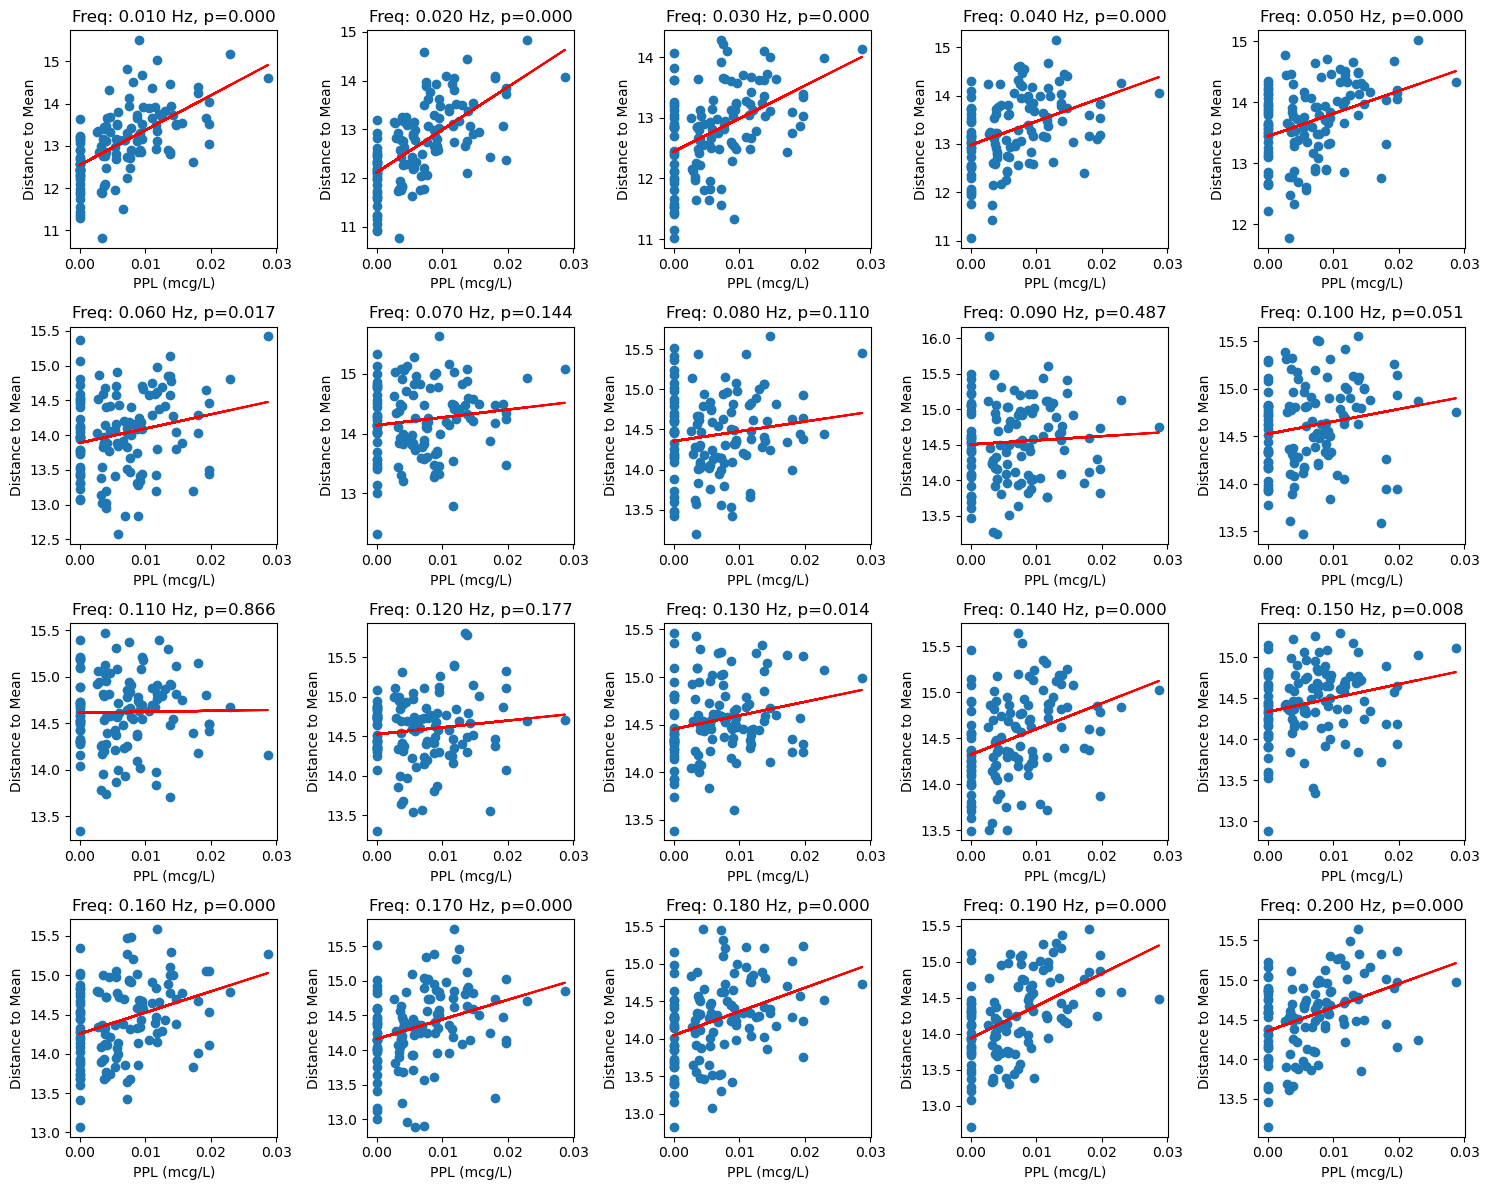

In [ ]:
plt.subplots(4,5, figsize=(15,12), tight_layout=True)
for f, freq in enumerate(frequencies):
    distance = distances[f]
    # spatial_maps = cov_broadband_array @ eigenvectors_array[:, freq_idx,:,:]
    # aligned, mean_basis, distance, delta = generalized_procrustes_subspaces(spatial_maps, tol=1e-9, max_iter=500)
    ax = plt.subplot(4,5,f+1)
    ax.plot(ppl_list, distance, 'o')
    na_idx = np.isnan(ppl_list)
    ppl_list2 = np.array(ppl_list)[~na_idx]
    distance2 = distance[~na_idx]
    # add line of best fit
    m, b = np.polyfit(ppl_list2, distance2, 1)
    # find the p-value of the correlation
    corr = np.corrcoef(ppl_list2, distance2)[0,1]

    pval = 1 - chi2.cdf((corr**2) * (len(ppl_list2) - 2) / (1 - corr**2), 1)
    # print(f'Correlation: {corr}, p-value: {pval}')

    ax.plot(ppl_list2, m*np.array(ppl_list2) + b, color='red')
    ax.set_xlabel('PPL (mcg/L)')
    ax.set_ylabel('Distance to Mean')
    ax.set_title('Freq: {:.3f} Hz, p={:.3f}'.format(frequencies[freq_idx], pval))